In [1]:
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
df_all = pd.read_csv('data/cases_by_region_month_all_models.csv')

model_ids = {
    'Climate(lag 1-5)': 'C15',
    'Climate(lag 1-5) + Month|region': 'C15-Mr',
    'Climate(lag 1-5) + PriorCases': 'C15-c(PC)',
    'Climate(lag 1-5) + SeroRepla': 'C15-c(SR)',
    'Climate(lag 1-5) + Socio': 'C15-c(S)',
    'Climate(lag 1-5) + Immunity': 'C15-c(IM)',
    'Year + Month': 'Y-M',
    'Month|region + PriorCases + SeroRepla + Socio + Immunity': 'Mr-c(PC,SR,S,IM)',
    'Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity': 'C15-c(PC,SR,S,IM)',
    'Year + Month + P(Climate)': 'Y-M-P(C)',
    'Climate(lag 1-5) + Year|region': 'C15-Yr',
    'Climate(lag 1) + Year|region + Month|region': 'C1-Yr-Mr',
    'Climate(lag 1-3) + Year|region + Month|region': 'C13-Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region': 'C15-Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region + SeroRepla': 'C15-Yr-Mr-c(SR)',
    'Climate(lag 1-5) + Year|region + Month|region + Immunity': 'C15-Yr-Mr-c(IM)',
    'Climate(lag 1-5) + Year|region + Month|region + Socio': 'C15-Yr-Mr-c(S)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases': 'C15-Yr-Mr-c(PC)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity': 'C15-Yr-Mr-c(PC,SR,S,IM)',
    'Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity': 'Yr-Mr-c(PC,SR,S,IM)',
    'Year|region + Month|region': 'Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio': 'C15-Yr-Mr-c(PC,SR,S)'
}


df_all['model_id'] = df_all['model_name'].map(model_ids)
df_all['region'] = df_all['region'].replace({'Middle-West': 'Centre-West'})

df_all

,model_name,region,date_first_symptoms,total_population,total_actual_cases,total_pred_cases,actual_incidence,predicted_incidence,model_id
0,Year + Month,Centre-West,2001-08-01,11605996,262,1350.202111,2.257454,11.633660,Y-M
1,Year + Month,Centre-West,2001-09-01,11605996,326,1053.753228,2.808893,9.079386,Y-M
2,Year + Month,Centre-West,2001-10-01,11605996,655,1103.041071,5.643635,9.504062,Y-M
3,Year + Month,Centre-West,2001-11-01,11605996,1636,1606.758597,14.096162,13.844211,Y-M
4,Year + Month,Centre-West,2001-12-01,11605996,1525,2420.427772,13.139760,20.854977,Y-M
...,...,...,...,...,...,...,...,...,...
28975,Month|region + PriorCases + SeroRepla + Socio ...,Southeast,2024-03-01,88562440,1079238,543818.159145,1218.618186,614.050560,"Mr-c(PC,SR,S,IM)"
28976,Month|region + PriorCases + SeroRepla + Socio ...,Southeast,2024-04-01,88562440,987358,564805.061456,1114.872174,637.747855,"Mr-c(PC,SR,S,IM)"
28977,Month|region + PriorCases + SeroRepla + Socio ...,Southeast,2024-05-01,88562440,709491,363067.793000,801.119527,409.956854,"Mr-c(PC,SR,S,IM)"
28978,Month|region + PriorCases + SeroRepla + Socio ...,Southeast,2024-06-01,88562440,184589,102235.062706,208.428088,115.438399,"Mr-c(PC,SR,S,IM)"


In [3]:
df_region = pd.read_csv('data/cases_by_region_month_all_models_by_region.csv')

model_ids = {
    'Climate(lag 1-5)': 'C15',
    'Climate(lag 1-5) + Month|region': 'C15-Mr',
    'Climate(lag 1-5) + PriorCases': 'C15-c(PC)',
    'Climate(lag 1-5) + SeroRepla': 'C15-c(SR)',
    'Climate(lag 1-5) + Socio': 'C15-c(S)',
    'Climate(lag 1-5) + Immunity': 'C15-c(IM)',
    'Year + Month': 'Y-M',
    'Month|region + PriorCases + SeroRepla + Socio + Immunity': 'Mr-c(PC,SR,S,IM)',
    'Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity': 'C15-c(PC,SR,S,IM)',
    'Year + Month + P(Climate)': 'Y-M-P(C)',
    'Climate(lag 1-5) + Year|region': 'C15-Yr',
    'Climate(lag 1) + Year|region + Month|region': 'C1-Yr-Mr',
    'Climate(lag 1-3) + Year|region + Month|region': 'C13-Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region': 'C15-Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region + SeroRepla': 'C15-Yr-Mr-c(SR)',
    'Climate(lag 1-5) + Year|region + Month|region + Immunity': 'C15-Yr-Mr-c(IM)',
    'Climate(lag 1-5) + Year|region + Month|region + Socio': 'C15-Yr-Mr-c(S)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases': 'C15-Yr-Mr-c(PC)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity': 'C15-Yr-Mr-c(PC,SR,S,IM)',
    'Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity': 'Yr-Mr-c(PC,SR,S,IM)',
    'Year|region + Month|region': 'Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio': 'C15-Yr-Mr-c(PC,SR,S)'
}


df_region['model_id'] = df_region['model_name'].map(model_ids)
df_region['region'] = df_region['region'].replace({'Middle-West': 'Centre-West'})

df_region

,model_name,region,date_first_symptoms,total_population,total_actual_cases,total_pred_cases,actual_incidence,predicted_incidence,model_id
0,Year|region + Month|region,North,2001-08-01,13546943,1282,714.785974,9.463390,5.276364,Yr-Mr
1,Year|region + Month|region,North,2001-09-01,13546943,1168,773.236165,8.621871,5.707828,Yr-Mr
2,Year|region + Month|region,North,2001-10-01,13546943,1488,926.029150,10.984028,6.835706,Yr-Mr
3,Year|region + Month|region,North,2001-11-01,13546943,2152,1512.526446,15.885503,11.165076,Yr-Mr
4,Year|region + Month|region,North,2001-12-01,13546943,2232,2033.711371,16.476042,15.012327,Yr-Mr
...,...,...,...,...,...,...,...,...,...
27595,Month|region + PriorCases + SeroRepla + Socio ...,South,2024-03-01,29968865,305512,283518.795765,1019.431333,946.044489,"Mr-c(PC,SR,S,IM)"
27596,Month|region + PriorCases + SeroRepla + Socio ...,South,2024-04-01,29968865,372420,349093.872345,1242.689705,1164.855167,"Mr-c(PC,SR,S,IM)"
27597,Month|region + PriorCases + SeroRepla + Socio ...,South,2024-05-01,29968865,239022,220472.986623,797.567742,735.673462,"Mr-c(PC,SR,S,IM)"
27598,Month|region + PriorCases + SeroRepla + Socio ...,South,2024-06-01,29968865,53940,55783.605953,179.986796,186.138534,"Mr-c(PC,SR,S,IM)"


/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_61292/466150958.py:89: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter([], [], s=10, color='k', marker='x', label='Regional Fit', edgecolor='k'),


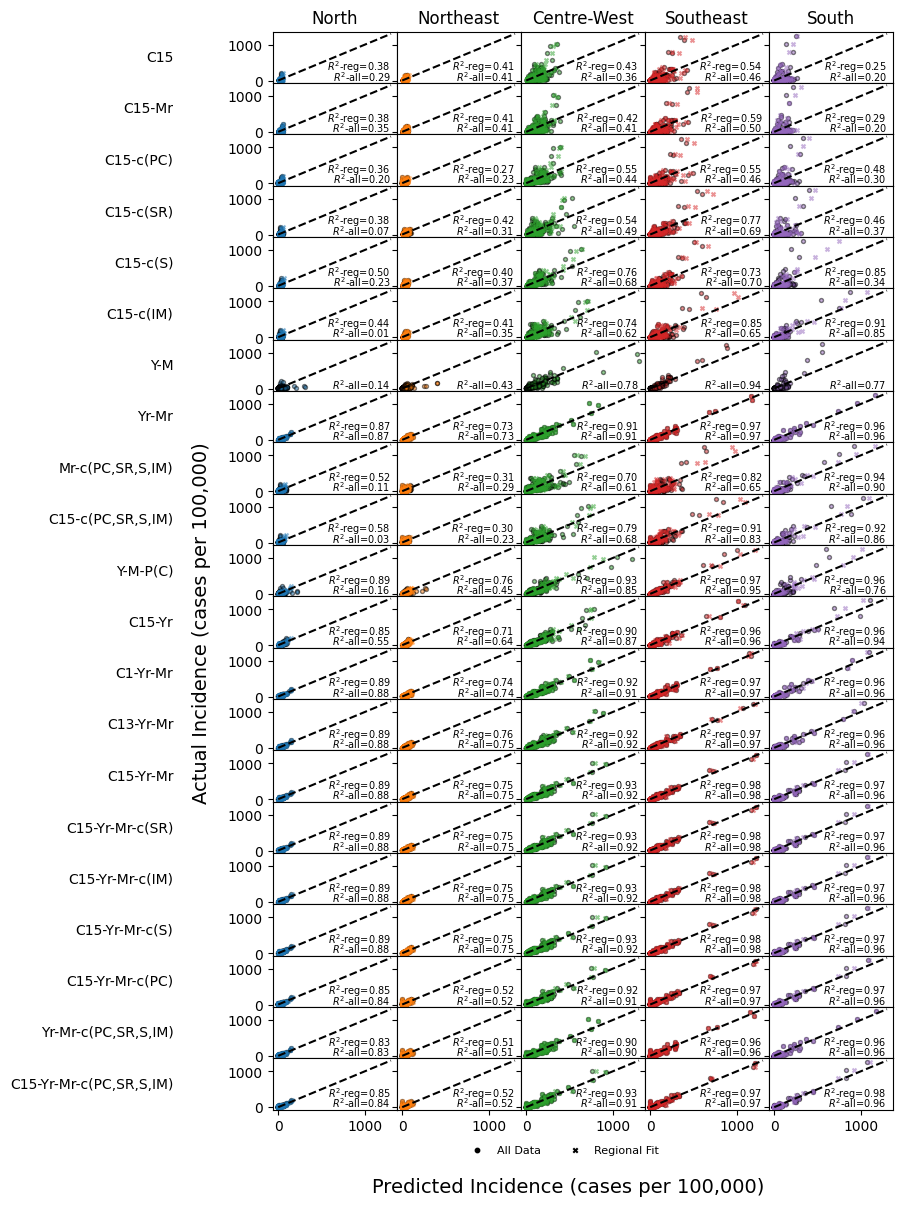

In [4]:
fig, axarr = plt.subplots(22, 5, sharex=True, sharey=True, figsize=(8,14.7))
fig.subplots_adjust(hspace=0.0, wspace=0.0)

order = [
    'C15',
    'C15-Mr',
    'C15-c(PC)',
    'C15-c(SR)',
    'C15-c(S)',
    'C15-c(IM)',
    'Y-M',
    'Yr-Mr',
    'Mr-c(PC,SR,S,IM)',
    'C15-c(PC,SR,S,IM)',
    'Y-M-P(C)',
    'C15-Yr',
    'C1-Yr-Mr',
    'C13-Yr-Mr',
    'C15-Yr-Mr',
    'C15-Yr-Mr-c(SR)',
    'C15-Yr-Mr-c(IM)',
    'C15-Yr-Mr-c(S)',
    'C15-Yr-Mr-c(PC)',
    'Yr-Mr-c(PC,SR,S,IM)',    
    'C15-Yr-Mr-c(PC,SR,S,IM)',
    'C15-Yr-Mr-c(PC,SR,S)'
]

vmax = max(
    df_all['predicted_incidence'].max(),
    df_all['actual_incidence'].max(),
)

for row, model in enumerate(order):
    df_all_subset = df_all[df_all['model_id'] == model]
    df_region_subset = df_region[df_region['model_id'] == model]

    for column, (region, color) in enumerate(
        zip(['North', 'Northeast', 'Centre-West', 'Southeast', 'South'], 
            ['C0', 'C1', 'C2', 'C3', 'C4'])
    ):

        ax = axarr[row, column]

        df_all_subset[df_all_subset['region'] == region].plot.scatter(
            x='predicted_incidence', 
            y='actual_incidence',
            ax=ax,
            color=color,
            s=8,
            alpha=0.5,
            edgecolor='k'
        )

        r2 = df_all_subset[df_all_subset['region'] == region][['predicted_incidence', 'actual_incidence']].corr().iloc[0, 1] ** 2

        ax.plot([0, vmax], [0, vmax], color='k', ls='--')
        ax.text(0.95, 0.00, f'$R^2$-all={r2:.2f}', transform=ax.transAxes, va='bottom', ha='right', fontsize=7)

        if not df_region_subset.empty:
            df_region_subset[df_region_subset['region'] == region].plot.scatter(
                x='predicted_incidence', 
                y='actual_incidence',
                ax=ax,
                color=color,
                marker='x',
                s=8,
                alpha=0.5
            )

            r2 = df_region_subset[df_region_subset['region'] == region][['predicted_incidence', 'actual_incidence']].corr().iloc[0, 1] ** 2
            ax.text(0.95, 0.16, f'$R^2$-reg={r2:.2f}', transform=ax.transAxes, va='bottom', ha='right', fontsize=7)

        ax.set_xlabel('')
        ax.set_ylabel('')

    axarr[row, 0].text(-0.8, 0.5, model, transform=axarr[row, 0].transAxes, va='center', ha='right')

axarr[0, 0].set_title('North')
axarr[0, 1].set_title('Northeast')
axarr[0, 2].set_title('Centre-West')
axarr[0, 3].set_title('Southeast')
axarr[0, 4].set_title('South')

axarr[-1, 2].text(-1.2, -1.5, 'Predicted Incidence (cases per 100,000)', fontsize=14, transform=axarr[-1, 2].transAxes, va='center')
axarr[11, 0].text(-0.5, 0.5, 'Actual Incidence (cases per 100,000)', transform=axarr[11, 0].transAxes, va='center', ha='right', rotation=90, fontsize=14)

legend_handles = [
    plt.scatter([], [], s=10, color='k', marker='o', label='All Data', edgecolor='k'),
    plt.scatter([], [], s=10, color='k', marker='x', label='Regional Fit', edgecolor='k'),
]

# === Add legend
axarr[-1, -2].legend(handles=legend_handles, frameon=False, fontsize=8, title_fontsize=8, bbox_to_anchor=(0.2, -0.5), ncol=2)


plt.savefig('img/predicted_vs_actual_incidence_by_region_and_model.png', dpi=300, bbox_inches='tight')
